
<div style="
background:linear-gradient(90deg,#0f172a,#1e3a8a);
padding:25px;
border-radius:12px;
color:white;
text-align:center;
">

<h1>🏠 Egyptian Real Estate Market</h1>

<h3>Exploratory Data Analysis (EDA)</h3>

<p>
A data-driven analysis of active real estate listings across Egypt's major regions,
uncovering pricing patterns, property characteristics, and market segmentation to
inform investment and pricing strategy.
</p>

</div>





##
<div style="
background:#f8fafc;
border-left:6px solid #0ea5e9;
padding:18px;
border-radius:10px;
">

<h2 style="color:#0369a1;">
📚 Libraries
</h2>

<p>
Core Python libraries used for data manipulation, numerical computation,
and visualization throughout this analysis.
</p>

</div>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
##
<div style="
background:#eef2ff;
border-left:6px solid #4f46e5;
padding:18px;
border-radius:10px;
">

<h2 style="color:#4338ca;">
📂 Load Dataset
</h2>

<p>
Load the preprocessed real estate listings dataset and preview its initial structure.
</p>

</div>


In [2]:
df = pd.read_csv('D:\\Estate-Miner\\Estate-Miner\\Data\\preprocessed_data.csv')
df.head()

,title,price,bedrooms,has_maid_room,bathrooms,area_sqm,property_type,available_from,location,amenities,...,available_month,available_day,price_per_sqm,amenities_count,total_rooms,price_per_bedroom,price_per_bathroom,area_per_bedroom,area_per_bathroom,amenities_per_room
0,A Full Sea view chalet 3BR for sale in north c...,16400000,3,True,3,140,Chalet,2026-04-30,"June, Ras Al Hekma, North Coast","Unfurnished, Balcony, Built in Wardrobes, Cent...",...,4,30,117142.857143,9,6,5.466667e+06,5.466667e+06,46.666667,46.666667,1.500000
1,Sea View Chalet 1BR In Fouka Bay Fully Finished,10500000,1,True,1,50,Chalet,2026-06-21,"Fouka Bay, Qesm Marsa Matrouh, North Coast","Unfurnished, Balcony, Built in Wardrobes, Cent...",...,6,21,210000.000000,9,2,1.050000e+07,1.050000e+07,50.000000,50.000000,4.500000
2,chalet 3bed ready to move prime location old p...,17500000,3,True,3,144,Chalet,2026-06-04,"Marassi, Sidi Abdel Rahman, North Coast","Unfurnished, Balcony, Built in Wardrobes, Cent...",...,6,4,121527.777778,9,6,5.833333e+06,5.833333e+06,48.000000,48.000000,1.500000
3,apartment 2bed for sale ready to move old price !,5000000,2,True,2,108,Apartment,2026-06-16,"Zed East, 5th Settlement Compounds, The 5th Se...","Unfurnished, Balcony, Built in Wardrobes, Cent...",...,6,16,46296.296296,9,4,2.500000e+06,2.500000e+06,54.000000,54.000000,2.250000
4,First Row Armani Standalone Villa 5BR with 5% DP!,250000000,5,True,6,325,Villa,2026-06-22,"Silver Sands, Qesm Marsa Matrouh, North Coast","Partly furnished, Balcony, Built in Wardrobes,...",...,6,22,769230.769231,9,11,5.000000e+07,4.166667e+07,65.000000,54.166667,0.818182


---
##
<div style="
background:#ecfeff;
border-left:6px solid #06b6d4;
padding:18px;
border-radius:10px;
">

<h2 style="color:#0e7490;">
📊 1. Dataset Overview
</h2>

<p>
Establish the dataset's size, structure, and feature composition before proceeding
to quality checks and deeper analysis.
</p>

</div>


In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 919
Columns: 45


**Column Data Types**

In [4]:
dtype_summary = df.dtypes.value_counts()
print(dtype_summary)
print()
df.dtypes

int64      28
object     10
float64     6
bool        1
Name: count, dtype: int64



title                          object
price                           int64
bedrooms                        int64
has_maid_room                    bool
bathrooms                       int64
area_sqm                        int64
property_type                  object
available_from                 object
location                       object
amenities                      object
area_sqft                       int64
region                         object
sub_area                       object
furnishing_status              object
amenities_no_furnishing        object
amenities_clean_list           object
amenity_balcony                 int64
amenity_built_in_wardrobes      int64
amenity_central_a_c             int64
amenity_children's_pool         int64
amenity_covered_parking         int64
amenity_kitchen_appliances      int64
amenity_lobby_in_building       int64
amenity_maids_room              int64
amenity_private_garden          int64
amenity_private_pool            int64
amenity_secu

**Sample Records (First and Last Rows)**

In [5]:
df.head(3)

,title,price,bedrooms,has_maid_room,bathrooms,area_sqm,property_type,available_from,location,amenities,...,available_month,available_day,price_per_sqm,amenities_count,total_rooms,price_per_bedroom,price_per_bathroom,area_per_bedroom,area_per_bathroom,amenities_per_room
0,A Full Sea view chalet 3BR for sale in north c...,16400000,3,True,3,140,Chalet,2026-04-30,"June, Ras Al Hekma, North Coast","Unfurnished, Balcony, Built in Wardrobes, Cent...",...,4,30,117142.857143,9,6,5.466667e+06,5.466667e+06,46.666667,46.666667,1.5
1,Sea View Chalet 1BR In Fouka Bay Fully Finished,10500000,1,True,1,50,Chalet,2026-06-21,"Fouka Bay, Qesm Marsa Matrouh, North Coast","Unfurnished, Balcony, Built in Wardrobes, Cent...",...,6,21,210000.000000,9,2,1.050000e+07,1.050000e+07,50.000000,50.000000,4.5
2,chalet 3bed ready to move prime location old p...,17500000,3,True,3,144,Chalet,2026-06-04,"Marassi, Sidi Abdel Rahman, North Coast","Unfurnished, Balcony, Built in Wardrobes, Cent...",...,6,4,121527.777778,9,6,5.833333e+06,5.833333e+06,48.000000,48.000000,1.5


In [6]:
df.tail(3)

,title,price,bedrooms,has_maid_room,bathrooms,area_sqm,property_type,available_from,location,amenities,...,available_month,available_day,price_per_sqm,amenities_count,total_rooms,price_per_bedroom,price_per_bathroom,area_per_bedroom,area_per_bathroom,amenities_per_room
916,First Row Villa | Fully Finished & 5% Downpayment,29800000,4,True,5,360,Villa,2026-06-18,"Ras Soma, Safaga, Hurghada, Red Sea","Partly furnished, Balcony, Built in Wardrobes,...",...,6,18,82777.777778,9,9,7.450000e+06,5960000.0,90.0,72.0,1.000000
917,1st row Fully Finished chalet with only 5% DP,13200000,3,True,4,180,Chalet,2026-06-21,"Almaza Bay, Qesm Marsa Matrouh, North Coast","Partly furnished, Balcony, Built in Wardrobes,...",...,6,21,73333.333333,9,7,4.400000e+06,3300000.0,60.0,45.0,1.285714
918,Last Chalet Premium Seaview on 10Y Installments,18200000,3,True,4,210,Chalet,2026-06-18,"Ras Soma, Safaga, Hurghada, Red Sea","Partly furnished, Balcony, Built in Wardrobes,...",...,6,18,86666.666667,9,7,6.066667e+06,4550000.0,70.0,52.5,1.285714


**Summary Statistics —> Numerical Features**

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,919.0,2.833054e+07,5.420071e+07,3.300000e+06,1.230000e+07,1.700000e+07,2.500000e+07,9.000000e+08
bedrooms,919.0,3.022851e+00,1.175513e+00,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,7.000000e+00
bathrooms,919.0,3.210011e+00,1.220052e+00,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,7.000000e+00
area_sqm,919.0,2.163330e+02,2.378990e+02,3.800000e+01,1.270000e+02,1.640000e+02,2.305000e+02,4.000000e+03
area_sqft,919.0,2.328587e+03,2.560736e+03,4.090000e+02,1.367000e+03,1.765000e+03,2.481000e+03,4.305600e+04
amenity_balcony,919.0,9.630033e-01,1.888565e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
amenity_built_in_wardrobes,919.0,8.509249e-01,3.563564e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
amenity_central_a_c,919.0,8.857454e-01,3.182935e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
amenity_children's_pool,919.0,2.176279e-02,1.459875e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
amenity_covered_parking,919.0,9.423286e-01,2.332479e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


**Summary Statistics —> Categorical Features**

In [8]:
df.describe(include=['object', 'category']).T

,count,unique,top,freq
title,919,753,Villa Finished On Lagoon Early Delivery Over 8...,15
property_type,919,10,Chalet,417
available_from,919,23,2026-06-22,375
location,919,112,"June, Ras Al Hekma, North Coast",60
amenities,919,331,"Unfurnished, Balcony, Built in Wardrobes, Cent...",258
region,919,5,North Coast,485
sub_area,919,112,June,60
furnishing_status,919,4,Unfurnished,469
amenities_no_furnishing,919,297,"Balcony, Built in Wardrobes, Central A/C, Cove...",409
amenities_clean_list,919,297,"['Balcony', 'Built In Wardrobes', 'Central A/C...",409


### 🔑 Key Insights — Dataset Overview

The dataset contains **919 property listings** across **45 features**, covering five major Egyptian regions: **North Coast, Cairo, Red Sea, Giza, and Suez**. It is already a **preprocessed dataset**, combining both raw listing attributes (e.g., price, area, bedrooms, bathrooms, property type, and location) and engineered features such as `price_per_sqm`, `amenities_count`, `price_per_bedroom`, and `area_per_bedroom`.

The feature set includes numerical variables, categorical variables, binary amenity indicators, and free-text fields, providing a rich foundation for both descriptive analysis and predictive modeling.

Overall, the dataset is well-structured and sufficiently comprehensive to support detailed market analysis, feature engineering, and machine learning tasks.

> **Next Step:** Before exploring market trends, the dataset quality is assessed to identify any issues that could affect the reliability of the analysis.


---
##
<div style="
background:#fef2f2;
border-left:6px solid #dc2626;
padding:18px;
border-radius:10px;
">

<h2 style="color:#b91c1c;">
🔍 2. Data Quality Assessment
</h2>

<p>
Evaluate missing values, duplicate records, invalid entries, and outliers to confirm
the dataset is reliable for downstream analysis.
</p>

</div>


In [9]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found in any column.")

Missing values per column:
No missing values found in any column.


In [10]:
duplicate_rows = df.duplicated().sum()
print(f"Fully duplicate rows: {duplicate_rows}")

Fully duplicate rows: 0


In [11]:
invalid_checks = {
    'price <= 0': (df['price'] <= 0).sum(),
    'area_sqm <= 0': (df['area_sqm'] <= 0).sum(),
    'bedrooms <= 0': (df['bedrooms'] <= 0).sum(),
    'bathrooms <= 0': (df['bathrooms'] <= 0).sum(),
    'bathrooms > bedrooms * 3': (df['bathrooms'] > df['bedrooms'] * 3).sum()
}
for check, count in invalid_checks.items():
    print(f"{check}: {count}")

price <= 0: 0
area_sqm <= 0: 0
bedrooms <= 0: 0
bathrooms <= 0: 0
bathrooms > bedrooms * 3: 0


In [12]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

for col in ['price', 'area_sqm', 'price_per_sqm', 'bedrooms', 'bathrooms']:
    print(f"{col}: {iqr_outlier_count(df[col])} outliers ")

price: 91 outliers 
area_sqm: 73 outliers 
price_per_sqm: 45 outliers 
bedrooms: 0 outliers 
bathrooms: 0 outliers 


### 🔑 Key Insights — Data Quality

The dataset is **structurally clean and analysis-ready**, with **no missing values** and **no fully duplicated records**. Most features are internally consistent, allowing the analysis to proceed without extensive data cleaning.

The primary quality considerations are:

- **`furnishing_status` contains an "Unknown" category** (86 listings, ~9%), representing unlabeled data rather than true missing values.
- **Suez includes only two listings**, making it statistically unreliable for regional comparisons and requiring caution during location-level analysis.
- **Price and area exhibit strong right-skewness**, driven by genuine luxury properties rather than data-entry errors. These observations are preserved and handled through logarithmic transformations and visualization techniques instead of removal.
- No inconsistencies were identified between the `area_sqm` and `area_sqft` measurements.

Overall, the dataset demonstrates high data quality, with only a few limitations that should be considered when interpreting regional statistics and extreme property values.

> **Next Step:** With data quality confirmed, the following section examines the distribution and statistical characteristics of each numerical feature.


---
##
<div style="
background:#faf5ff;
border-left:6px solid #9333ea;
padding:18px;
border-radius:10px;
">

<h2 style="color:#7e22ce;">
📈 3. Univariate Analysis
</h2>

<p>
Examine the distribution of key numerical and categorical features individually to
understand the shape and composition of the market before exploring relationships
between variables.
</p>

</div>




### 3.1 Numerical Features

Distribution shape, spread, and skewness of price, area, and room-count variables.


In [13]:
key_numerical = ['price', 'area_sqm', 'bedrooms', 'bathrooms', 'price_per_sqm', 'amenities_count']

stats_table = pd.DataFrame({
    'Mean': df[key_numerical].mean(),
    'Median': df[key_numerical].median(),
    'Std Dev': df[key_numerical].std(),
    'Skewness': df[key_numerical].skew(),
    'Kurtosis': df[key_numerical].kurt(),
    'Min': df[key_numerical].min(),
    'Max': df[key_numerical].max(),
})
stats_table.round(2)

,Mean,Median,Std Dev,Skewness,Kurtosis,Min,Max
price,28330536.06,17000000.00,54200714.54,10.57,150.67,3300000.00,9.000000e+08
area_sqm,216.33,164.00,237.90,10.03,143.58,38.00,4.000000e+03
bedrooms,3.02,3.00,1.18,0.94,1.63,1.00,7.000000e+00
bathrooms,3.21,3.00,1.22,0.87,1.19,1.00,7.000000e+00
price_per_sqm,117836.72,108333.33,63624.43,4.49,38.12,28695.65,8.615385e+05
amenities_count,8.90,9.00,1.00,-5.13,29.95,1.00,1.000000e+01


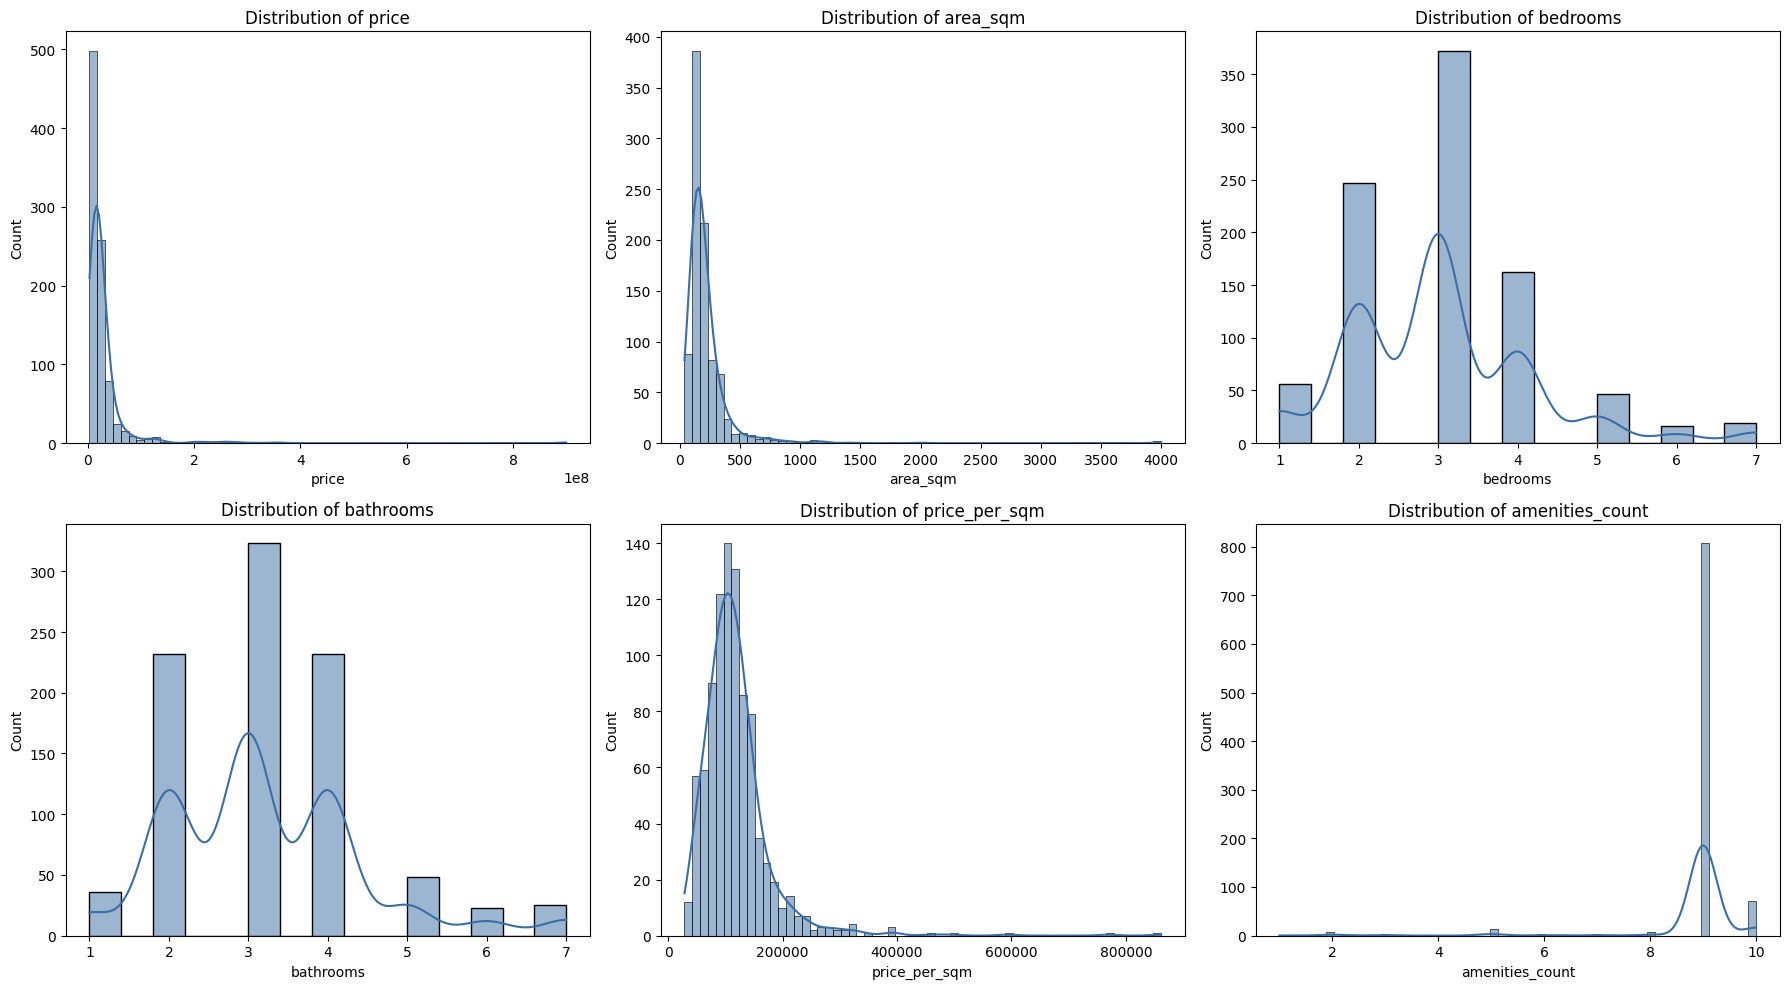

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_numerical):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#3b6ea5')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

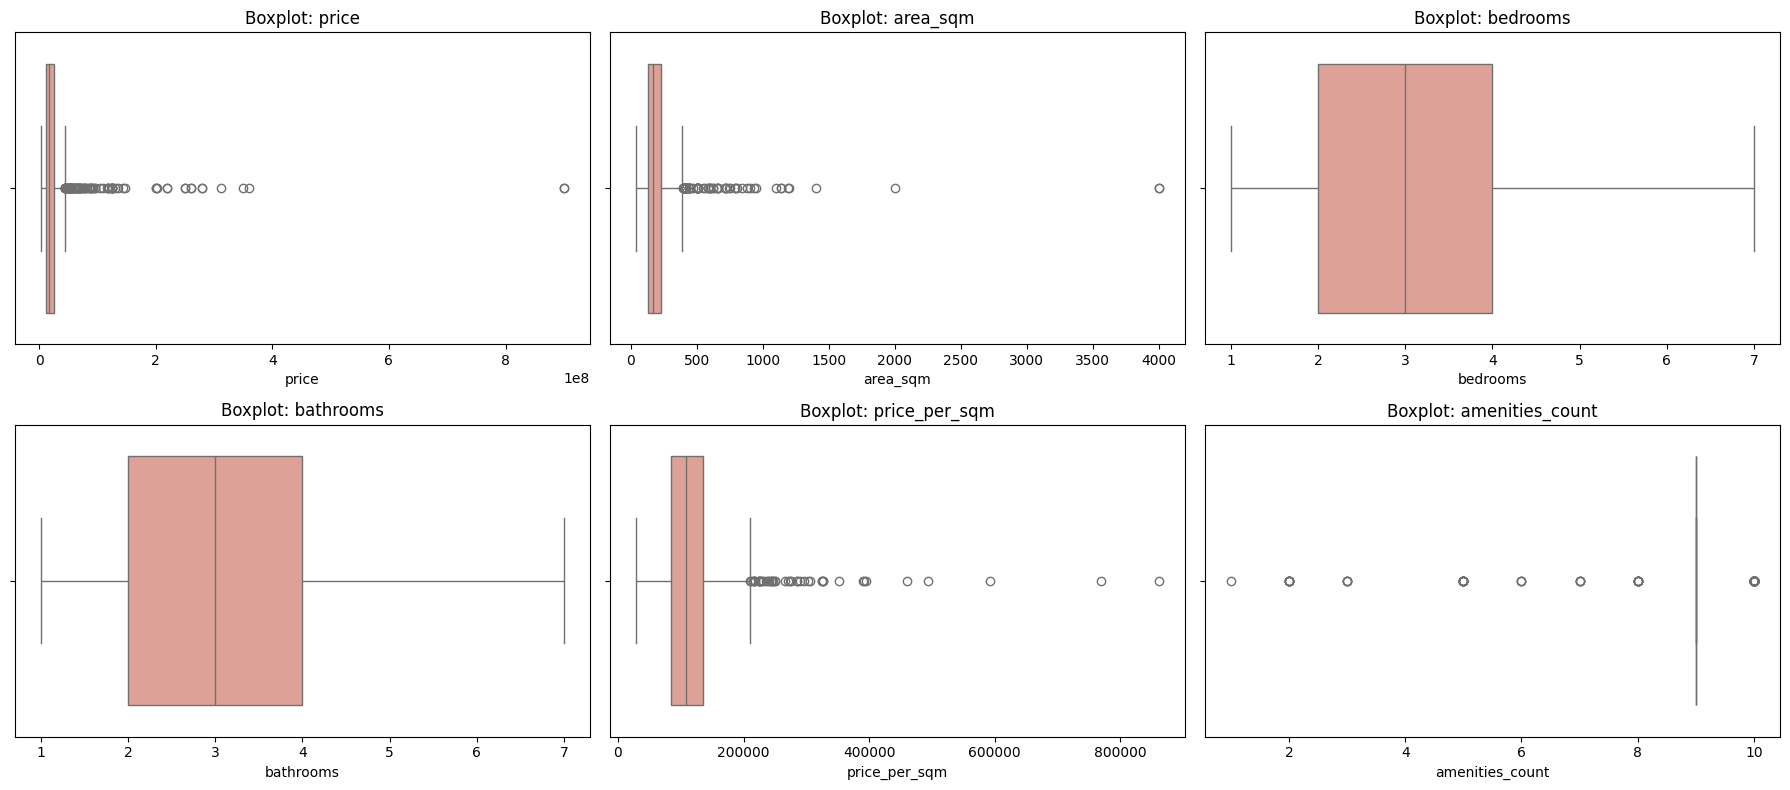

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(key_numerical):
    sns.boxplot(x=df[col], ax=axes[i], color='#e8998d')
    axes[i].set_title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()

### 🔑 Key Insights — Numerical Features

The numerical variables reveal several characteristics typical of real estate datasets:

- **`price`** is highly right-skewed, with a long tail of luxury properties that raises the mean well above the median, indicating a premium market segment.
- **`area_sqm`** also exhibits strong right-skewness, driven by a relatively small number of exceptionally large luxury properties.
- **`bedrooms`** and **`bathrooms`** are discrete variables concentrated around 2–4 rooms, with fewer large residential properties extending the upper tail.
- **`price_per_sqm`** follows a more balanced distribution but still contains a noticeable right tail, suggesting significant location- and property-type premiums.
- **`amenities_count`** is tightly concentrated around 8–9 amenities, indicating that most listings provide a similar set of standard facilities.

Overall, the numerical distributions reveal the presence of skewness and genuine market outliers, reinforcing the need for robust statistical methods and logarithmic transformations in subsequent analyses.

> **Next Step:** After understanding the numerical variables, the analysis shifts to the distribution of categorical features to examine the composition of the property market.


### 3.2 Categorical Features

Composition of property type, region, and furnishing status across the listings.


In [16]:
cat_features = ['property_type', 'region', 'furnishing_status']

for col in cat_features:
    print(f"--- {col} ---")
    freq = df[col].value_counts()
    pct = (df[col].value_counts(normalize=True) * 100).round(1)
    print(pd.DataFrame({'Count': freq, 'Percentage': pct}))
    print()

--- property_type ---
                Count  Percentage
property_type                    
Chalet            417        45.4
Villa             208        22.6
Apartment         174        18.9
Townhouse          42         4.6
Twin House         35         3.8
Duplex             22         2.4
Penthouse          14         1.5
Whole Building      3         0.3
Cabin               2         0.2
Ivilla              2         0.2

--- region ---
             Count  Percentage
region                        
North Coast    485        52.8
Cairo          184        20.0
Red Sea        165        18.0
Giza            83         9.0
Suez             2         0.2

--- furnishing_status ---
                   Count  Percentage
furnishing_status                   
Unfurnished          469        51.0
Partly furnished     320        34.8
Unknown               86         9.4
Furnished             44         4.8



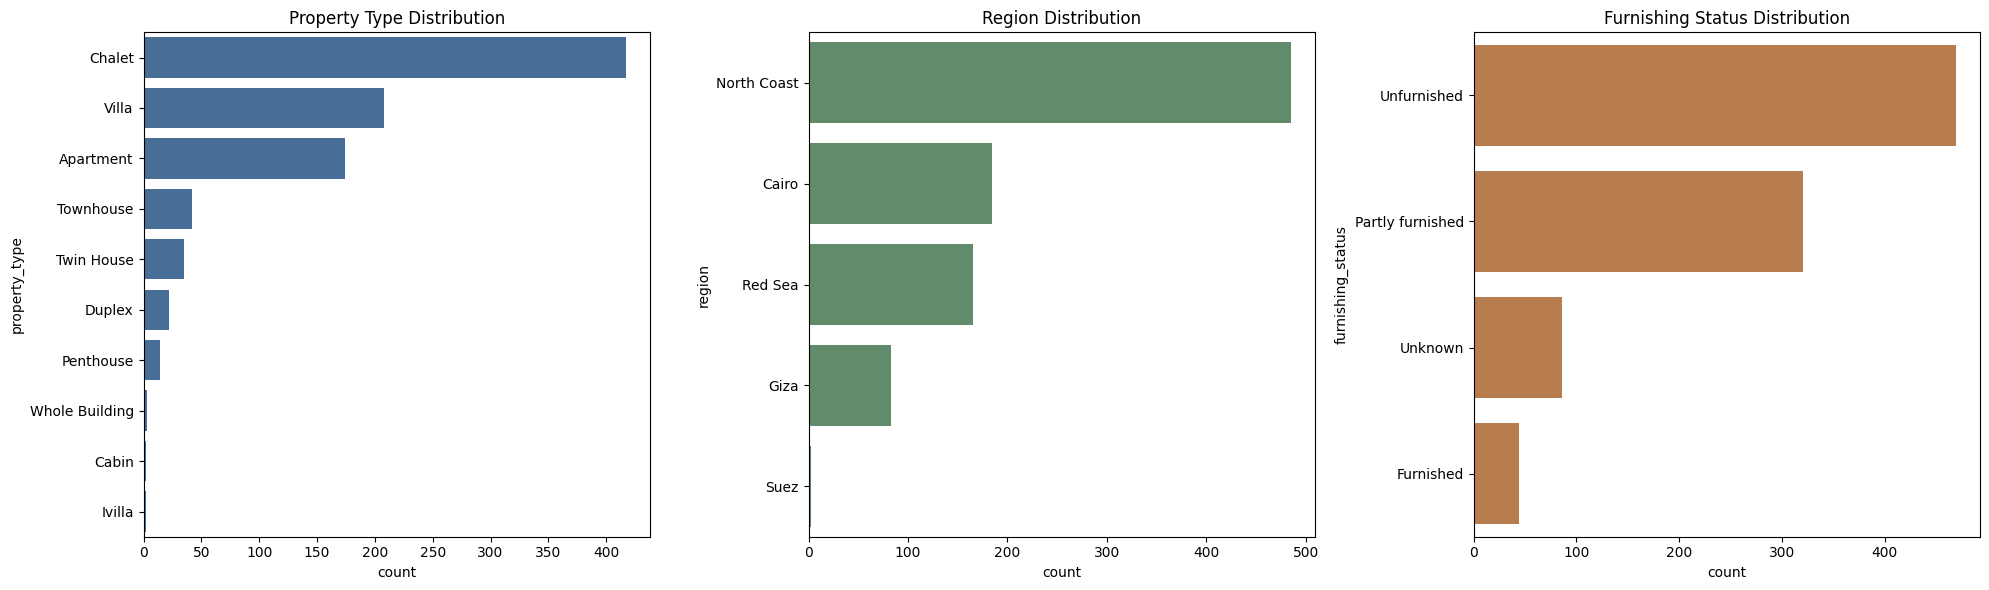

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.countplot(data=df, y='property_type', order=df['property_type'].value_counts().index, ax=axes[0], color='#3b6ea5')
axes[0].set_title('Property Type Distribution')

sns.countplot(data=df, y='region', order=df['region'].value_counts().index, ax=axes[1], color='#5a9367')
axes[1].set_title('Region Distribution')

sns.countplot(data=df, y='furnishing_status', order=df['furnishing_status'].value_counts().index, ax=axes[2], color='#c97b3d')
axes[2].set_title('Furnishing Status Distribution')

plt.tight_layout()
plt.show()

### 🔑 Key Insights — Categorical Features

The categorical variables provide valuable insights into the composition of the Egyptian real estate market represented in this dataset.

- **Property Type:** `Chalet` (45%) and `Villa` (23%) dominate the dataset, reflecting the strong concentration of holiday homes in the North Coast and Red Sea regions. Apartments account for 19%, while Townhouses, Twin Houses, Duplexes, and Penthouses represent smaller market segments. A few categories (e.g., `Whole Building`, `Cabin`, and `Ivilla`) contain only a handful of observations and should be treated as rare classes.
- **Region:** The **North Coast** accounts for more than half of all listings (53%), followed by **Cairo** (20%), **Red Sea** (18%), and **Giza** (9%). **Suez** contributes only two listings and is therefore excluded from meaningful regional comparisons.
- **Furnishing Status:** `Unfurnished` properties represent the largest share (51%), followed by `Partly furnished` (35%). The `Unknown` category (9%) reflects incomplete labeling rather than an actual furnishing condition.

These distributions indicate that the dataset is heavily weighted toward coastal holiday properties, a factor that should be considered when interpreting market trends and building predictive models.

> **Next Step:** Having explored the dataset composition, the next section focuses on the target variable—property price—to understand its distribution, variability, and extreme values.



---
##
<div style="
background:#ecfdf5;
border-left:6px solid #16a34a;
padding:18px;
border-radius:10px;
">

<h2 style="color:#15803d;">
💰 4. Price Analysis
</h2>

<p>
Examine the target variable in detail — its distribution, tiering, and outlier
structure — to establish a foundation for pricing strategy and future predictive
modeling.
</p>

</div>


In [18]:
price_stats = df['price'].describe(percentiles=[ .25, .5, .75, .99])
price_stats

count    9.190000e+02
mean     2.833054e+07
std      5.420071e+07
min      3.300000e+06
25%      1.230000e+07
50%      1.700000e+07
75%      2.500000e+07
99%      2.500000e+08
max      9.000000e+08
Name: price, dtype: float64

In [19]:
print(f"Minimum price: {df['price'].min():,.0f} EGP")
print(f"Maximum price: {df['price'].max():,.0f} EGP")
print(f"Price range: {df['price'].max() - df['price'].min():,.0f} EGP")
print(f"Mean price: {df['price'].mean():,.0f} EGP")
print(f"Median price: {df['price'].median():,.0f} EGP")
print(f"Skewness: {df['price'].skew():.2f}")
print(f"Kurtosis: {df['price'].kurt():.2f}")

Minimum price: 3,300,000 EGP
Maximum price: 900,000,000 EGP
Price range: 896,700,000 EGP
Mean price: 28,330,536 EGP
Median price: 17,000,000 EGP
Skewness: 10.57
Kurtosis: 150.67


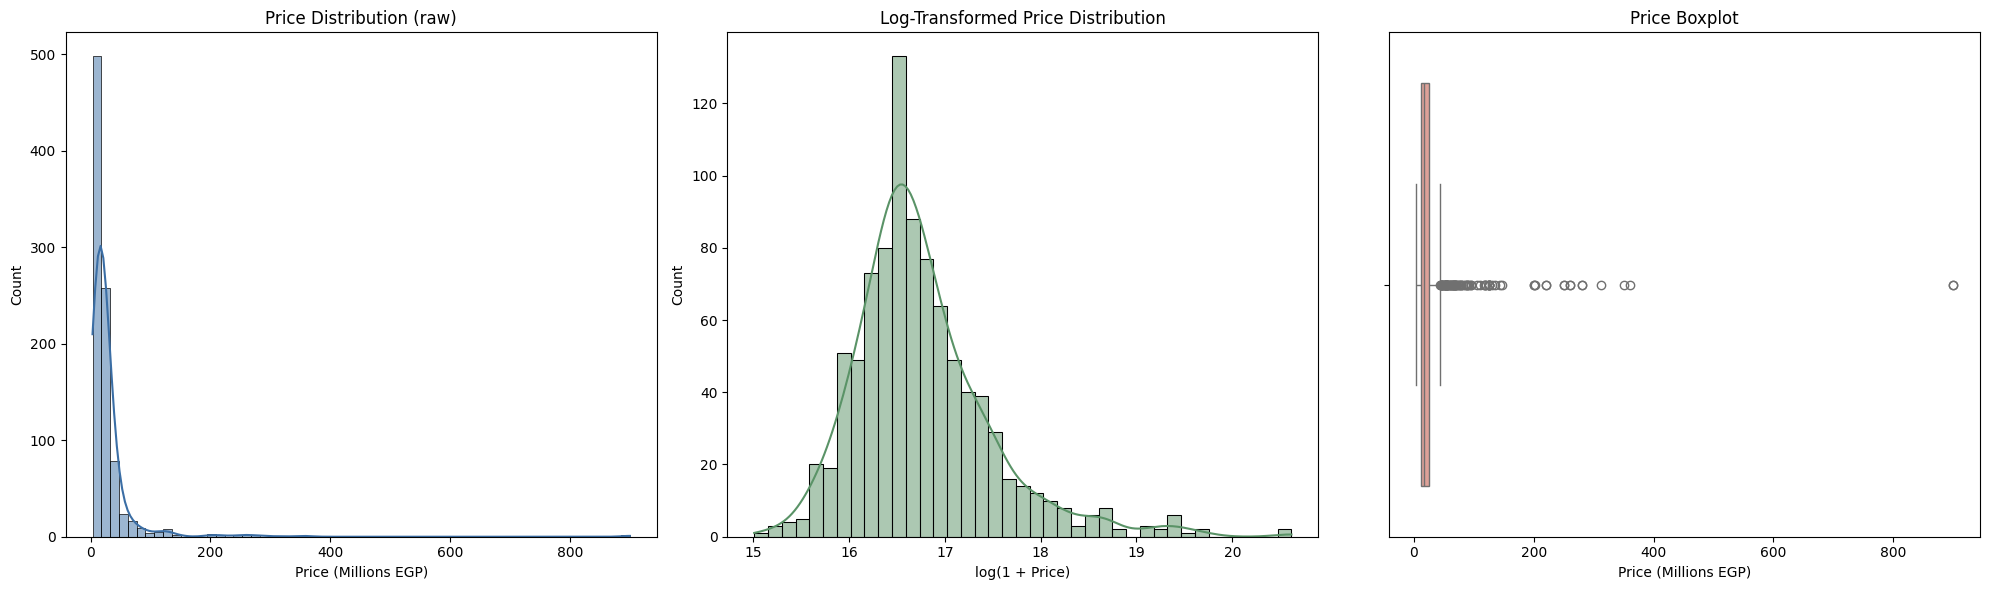

In [20]:
df['price_m'] = df['price'] / 1e6  # price in millions EGP
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.histplot(df['price_m'], kde=True, ax=axes[0], color='#3b6ea5')
axes[0].set_title('Price Distribution (raw)')
axes[0].set_xlabel('Price (Millions EGP)')

log_price = np.log1p(df['price'])
sns.histplot(log_price, kde=True, ax=axes[1], color='#5a9367')
axes[1].set_title('Log-Transformed Price Distribution')
axes[1].set_xlabel('log(1 + Price)')

sns.boxplot(x=df['price_m'], ax=axes[2], color='#e8998d')
axes[2].set_title('Price Boxplot')
axes[2].set_xlabel('Price (Millions EGP)')

plt.tight_layout()
plt.show()

In [21]:
# Define price ranges (tiers) for business interpretation
bins = [0, 1e7, 2e7, 3e7, 5e7, np.inf]
labels = ['<10M', '10-20M', '20-30M', '30-50M', '50M+']
df['price_tier'] = pd.cut(df['price'], bins=bins, labels=labels)

tier_counts = df['price_tier'].value_counts().reindex(labels)
tier_pct = (tier_counts / len(df) * 100).round(1)
pd.DataFrame({'Count': tier_counts, 'Percentage': tier_pct})

,Count,Percentage
price_tier,,
<10M,139,15.1
10-20M,446,48.5
20-30M,158,17.2
30-50M,97,10.6
50M+,79,8.6


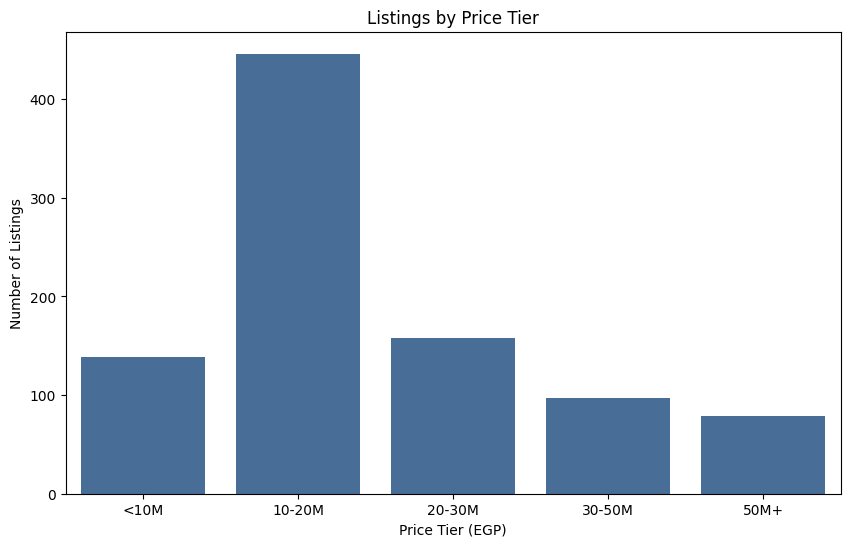

In [22]:
plt.figure(figsize=(10, 6))
sns.countplot(x=df['price_tier'], order=labels, color='#3b6ea5')
plt.title('Listings by Price Tier')
plt.xlabel('Price Tier (EGP)')
plt.ylabel('Number of Listings')
plt.show()

In [23]:
q1, q3 = df['price'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
outliers = df[df['price'] > upper_fence]
print(f"Upper fence (IQR method): {upper_fence:,.0f} EGP")
print(f"Number of price outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}% of listings)")
print(f"These outliers span: {outliers['price'].min():,.0f} to {outliers['price'].max():,.0f} EGP")
outliers[['title', 'price', 'property_type', 'region', 'area_sqm']].sort_values('price', ascending=False).head(10)

Upper fence (IQR method): 44,050,000 EGP
Number of price outliers: 91 (9.9% of listings)
These outliers span: 44,100,000 to 900,000,000 EGP


,title,price,property_type,region,area_sqm
777,Last Building with Immediate Delivery OVER 10 ...,900000000,Whole Building,Cairo,4000
778,Last Building with Immediate Delivery OVER 10 ...,900000000,Whole Building,Cairo,4000
169,Luxuries 1St Row At Marassi Bay With Private Pool,360000000,Villa,North Coast,1190
158,First Row Golf Fully Finished 1400m Luxury Villa,350000000,Villa,Cairo,1400
668,First Row NOBU Standalone Villa 7BR with 5% DP!,312000000,Villa,North Coast,1135
669,First Row Armani Standalone Villa 7BR with 5% DP!,280000000,Villa,North Coast,1135
670,First Row Armani Standalone Villa 5BR with 5% DP!,280000000,Villa,North Coast,325
232,Luxury Sea Front Villa Direct on Marassi Bay,260000000,Villa,North Coast,1100
170,Luxuries Sea Front villa At Marassi - VALINCIA,260000000,Villa,North Coast,2000
4,First Row Armani Standalone Villa 5BR with 5% DP!,250000000,Villa,North Coast,325


### 🔑 Key Insights — Price Analysis

Property prices range from **3.3 million EGP to 900 million EGP**, with a median of **17 million EGP**. The mean (**28.3 million EGP**) is substantially higher than the median, confirming a pronounced right-skew caused by a relatively small number of ultra-luxury properties.

Applying a logarithmic transformation significantly improves the distribution, making **log(price)** a more suitable target variable for regression-based machine learning models.

Key observations include:

- **91 listings (9.9% of the dataset)** are identified as statistical outliers using the IQR method. Manual inspection indicates that these properties are primarily luxury villas and premium developments rather than erroneous records.
- The middle 50% of listings fall between **12.3 million and 25 million EGP**, representing the typical price range within this dataset.
- Extreme property prices reflect genuine market variability and should be managed using robust modeling techniques rather than removed from the dataset.

Overall, the analysis confirms that the dataset contains authentic luxury-market observations, making logarithmic transformation and robust modeling approaches appropriate for predictive analysis.

> **Next Step:** With pricing behavior established, the following section investigates how property values vary across different regions and sub-areas within the Egyptian real estate market.



---
##
<div style="
background:#fff7ed;
border-left:6px solid #ea580c;
padding:18px;
border-radius:10px;
">

<h2 style="color:#c2410c;">
📍 5. Location Analysis
</h2>

<p>
Break down pricing and listing volume by region and sub-area to identify where value
concentrates geographically and how location interacts with property type.
</p>

</div>


In [24]:
region_summary = df.groupby('region').agg(
    listing_count=('price', 'count'),
    avg_price=('price', 'mean'),
    median_price=('price', 'median'),
    avg_area=('area_sqm', 'mean'),
    avg_price_per_sqm=('price_per_sqm', 'mean'),
).round(0).sort_values('avg_price', ascending=False)
region_summary

,listing_count,avg_price,median_price,avg_area,avg_price_per_sqm
region,,,,,
Cairo,184,36170756.0,16000000.0,285.0,95120.0
North Coast,485,30084700.0,18000000.0,210.0,130713.0
Red Sea,165,19625599.0,16000000.0,171.0,117200.0
Giza,83,18365546.0,14600000.0,189.0,94762.0
Suez,2,13350000.0,13350000.0,140.0,95357.0


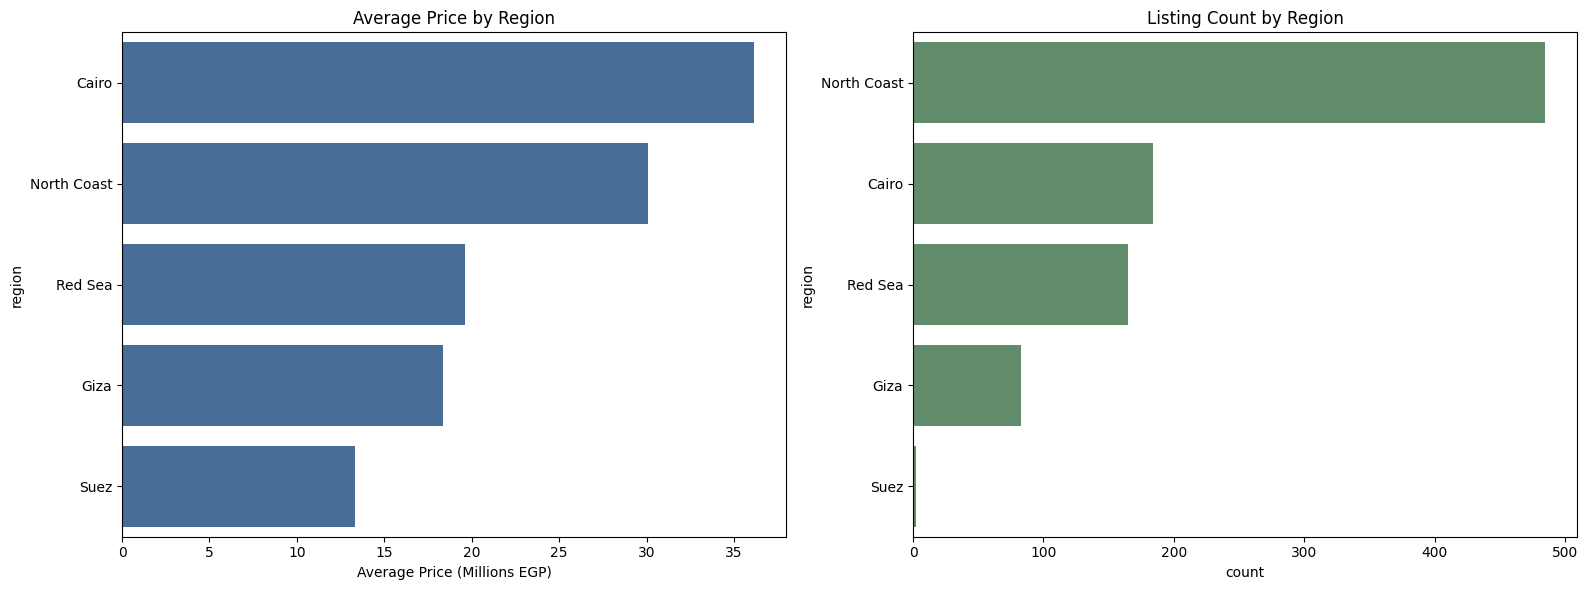

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order = region_summary.index
sns.barplot(x=region_summary['avg_price'] / 1e6, y=order, ax=axes[0], color='#3b6ea5')
axes[0].set_title('Average Price by Region')
axes[0].set_xlabel('Average Price (Millions EGP)')

sns.countplot(data=df, y='region', order=df['region'].value_counts().index, ax=axes[1], color='#5a9367')
axes[1].set_title('Listing Count by Region')

plt.tight_layout()
plt.show()

In [26]:
# Sub-area ranking (restricted to sub-areas with a meaningful sample size)
sub_area_summary = df.groupby('sub_area').agg(
    listing_count=('price', 'count'),
    avg_price=('price', 'mean'),
    median_price=('price', 'median'),
    avg_area=('area_sqm', 'mean'),
    avg_price_per_sqm=('price_per_sqm', 'mean'),
).round(0)

reliable_sub_areas = sub_area_summary[sub_area_summary['listing_count'] >= 5]
print(f"Sub-areas with >= 5 listings: {len(reliable_sub_areas)} out of {len(sub_area_summary)} total")

top10_expensive = reliable_sub_areas.sort_values('avg_price', ascending=False).head(10)
top10_cheapest = reliable_sub_areas.sort_values('avg_price', ascending=True).head(10)
top10_volume = reliable_sub_areas.sort_values('listing_count', ascending=False).head(10)

Sub-areas with >= 5 listings: 53 out of 112 total


In [27]:
print("Top 10 most expensive sub-areas :")
top10_expensive

Top 10 most expensive sub-areas :


,listing_count,avg_price,median_price,avg_area,avg_price_per_sqm
sub_area,,,,,
Villette,8,140498750.0,30995000.0,821.0,101073.0
Mivida,19,96905263.0,36000000.0,544.0,140039.0
Marassi,45,71059565.0,27500000.0,392.0,171343.0
Almaza Bay,34,48221636.0,35000000.0,264.0,166898.0
Ogami,17,47403529.0,32300000.0,271.0,144580.0
City Gate,5,47200000.0,34000000.0,422.0,107619.0
Swan Lake West,10,38193100.0,23000000.0,305.0,117282.0
Cairo Festival City,7,37540714.0,26800000.0,272.0,128662.0
Modon Abu Dhabi,20,36215000.0,20000000.0,220.0,140942.0


In [28]:
print("Top 10 cheapest sub-areas :")
top10_cheapest

Top 10 cheapest sub-areas :


,listing_count,avg_price,median_price,avg_area,avg_price_per_sqm
sub_area,,,,,
The Address East,11,7406909.0,7665000.0,149.0,50050.0
Mountain View iCity,6,9358333.0,7100000.0,182.0,52056.0
Park Side Residence,16,9665998.0,8000000.0,122.0,80431.0
Mountain View Hyde Park,13,9690769.0,8000000.0,165.0,60627.0
Hacienda Bay,8,9768750.0,10000000.0,125.0,99164.0
Badya Palm Hills,5,9800000.0,9000000.0,133.0,72761.0
Gaia,5,11771738.0,7768650.0,95.0,167322.0
Village West,7,12571429.0,10900000.0,150.0,83625.0
Elan,6,14875774.0,14250000.0,137.0,108437.0


In [29]:
print("Top 10 sub-areas by listing volume:")
top10_volume

Top 10 sub-areas by listing volume:


,listing_count,avg_price,median_price,avg_area,avg_price_per_sqm
sub_area,,,,,
June,60,22784859.0,16887650.0,183.0,126364.0
Silver Sands,58,21515498.0,13935000.0,169.0,120580.0
Mesca,46,18383913.0,17150000.0,168.0,115178.0
Marassi,45,71059565.0,27500000.0,392.0,171343.0
Almaza Bay,34,48221636.0,35000000.0,264.0,166898.0
Ramla,32,32561551.0,22500000.0,215.0,143625.0
Marsa Baghush,30,25320630.0,18500000.0,189.0,127158.0
Palm Hills New Cairo,28,17200768.0,14900000.0,250.0,78137.0
Makadi Heights,27,15755593.0,13250000.0,162.0,103733.0


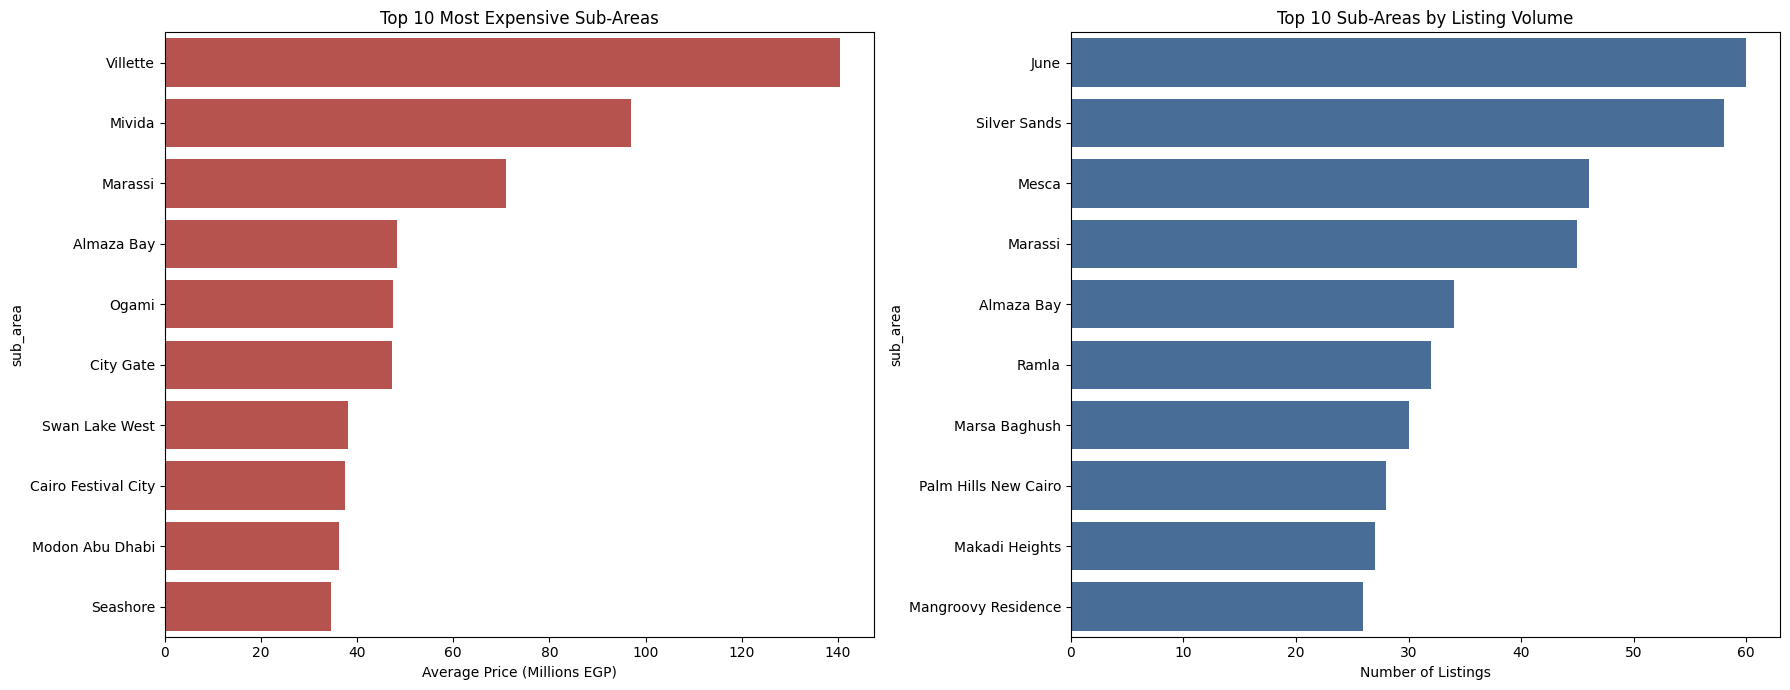

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(x=top10_expensive['avg_price'] / 1e6, y=top10_expensive.index, ax=axes[0], color='#c9433d')
axes[0].set_title('Top 10 Most Expensive Sub-Areas')
axes[0].set_xlabel('Average Price (Millions EGP)')

sns.barplot(x=top10_volume['listing_count'], y=top10_volume.index, ax=axes[1], color='#3b6ea5')
axes[1].set_title('Top 10 Sub-Areas by Listing Volume')
axes[1].set_xlabel('Number of Listings')

plt.tight_layout()
plt.show()

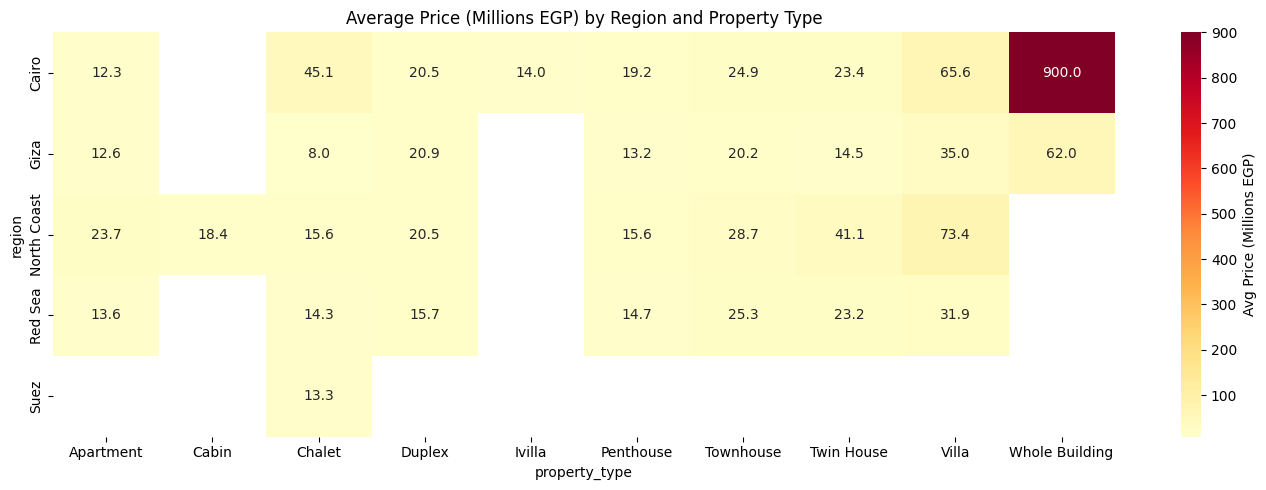

In [31]:
# Heatmap: region x property_type average price
pivot = df.pivot_table(index='region', columns='property_type', values='price', aggfunc='mean')
plt.figure(figsize=(14, 5))
sns.heatmap(pivot / 1e6, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Avg Price (Millions EGP)'})
plt.title('Average Price (Millions EGP) by Region and Property Type')
plt.tight_layout()
plt.show()

### 🔑 Key Insights — Location Analysis

Location is one of the strongest drivers of property value within the dataset.

- **Cairo** records the highest average property price (~36.2 million EGP), largely driven by premium developments in New Cairo and the Fifth Settlement.
- **North Coast** follows with an average price of approximately **30.1 million EGP**, reflecting the high demand for luxury vacation properties.
- **Giza** represents the most affordable major region (~18.4 million EGP), offering lower average prices despite its proximity to Cairo.
- The **North Coast** dominates listing volume with **485 properties (53% of the dataset)**, indicating that the dataset primarily represents the coastal holiday-home market rather than the entire Egyptian housing market.
- At the sub-area level, the highest-priced locations are concentrated in exclusive North Coast developments and premium compounds in New Cairo, while high-volume areas such as **June** and **Silver Sands** represent the broader chalet market.
- The Region × Property Type heatmap further demonstrates that **Villas** and **Twin Houses** consistently command the highest average prices across nearly all regions, whereas **Apartments** and **Chalets** occupy the lower pricing tiers.

Overall, the findings confirm that both **geographical location** and **property type** play a fundamental role in determining property values, making them among the most influential features for subsequent predictive modeling.